In [25]:
from io import BytesIO
from pathlib import Path
from zipfile import ZipFile

import pandas as pd

In [26]:
DATA_BASE_PATH = Path("./data").resolve().absolute()
TAXI_ZIP_PATH = DATA_BASE_PATH / "beijing_taxi_logs.parquet.zip"

TAXI_ID = 2

In [27]:
def get_parquet_from_zip(taxi_id: int | str) -> BytesIO:
    with ZipFile(TAXI_ZIP_PATH, "r") as zfile:
        # Procura o arquivo que contém o taxi_id no nome
        taxi_id = str(taxi_id)
        for filename in zfile.namelist():
            if taxi_id in filename and filename.endswith(".parquet"):
                with zfile.open(filename) as parquet_file:
                    return BytesIO(parquet_file.read())
        raise FileNotFoundError(
            f"Arquivo Parquet para taxi_id {taxi_id} não encontrado."
        )

In [28]:
taxi_parquet = get_parquet_from_zip(TAXI_ID)
df = pd.read_parquet(taxi_parquet)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1413 entries, 0 to 1412
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   taxi_id             1413 non-null   int64         
 1   recorded_timestamp  1413 non-null   datetime64[us]
 2   lon                 1413 non-null   float64       
 3   lat                 1413 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(1)
memory usage: 44.3 KB


array([<Axes: title={'center': 'Longitude over Time'}, xlabel='recorded_timestamp'>,
       <Axes: title={'center': 'Latitude over Time'}, xlabel='recorded_timestamp'>],
      dtype=object)

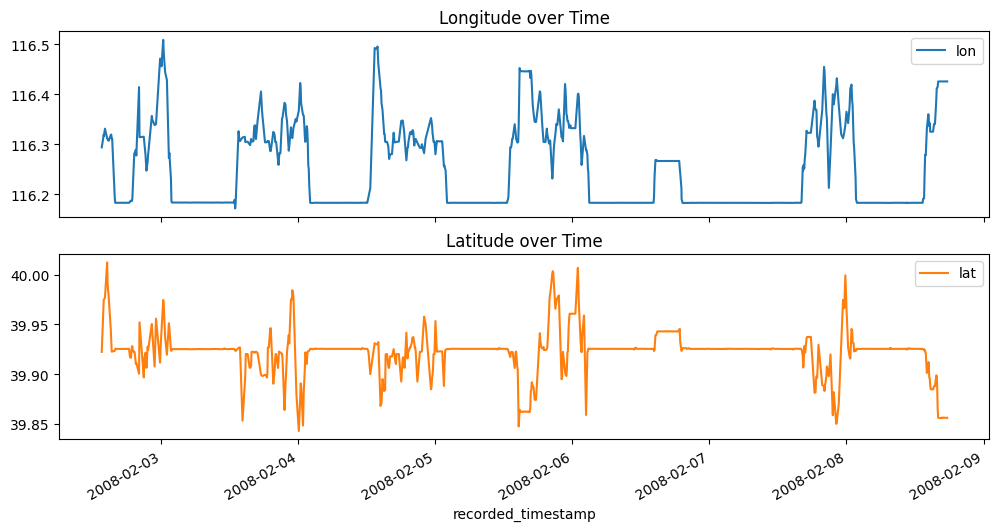

In [29]:
df.plot(
    x="recorded_timestamp",
    y=["lon", "lat"],
    subplots=True,
    figsize=(12, 6),
    title=["Longitude over Time", "Latitude over Time"],
)